# 03 - Ekstraksi Dataset Antropogenik & Kependudukan Resmi BPS (2021–2024)
**Kompetisi**: Airlangga Statistics Essay Competition (ASEC) 2026 — Arsen Unair  
**Tim Peneliti**: Mutia & Reno (Universitas Gadjah Mada)  
**Kategori**: Pilar 3 — Antropogenik & Tekanan Kependudukan (*Anthropogenic & Demographic Landward Squeeze*)  
**Kepatuhan Temporal**: 100% Mematuhi Aturan 5 Tahun Terakhir (Data BPS 2021–2024 & ESA WorldCover 2021)  

---

### Deskripsi & Ruang Lingkup Analisis
Notebook ini secara khusus membedah pilar **Antropogenik & Kependudukan** yang membentuk penghalang keras di sisi darat (*landward barrier*), sehingga ekosistem mangrove terjepit di antara ancaman laut (subsidensi & abrasi) dan aktivitas manusia:
1. **Ekstraksi Data Kependudukan BPS (2021–2024)**: Mengolah data resmi BPS Kabupaten/Kota untuk 5 kluster pesisir Pantura Jawa secara runtut waktu (*time-series*).
2. **Ekstraksi Lahan Terbangun (*Built-Up Land*, Class 50 ESA WorldCover 10m)**: Menghitung luas pemukiman, kawasan industri, jalan nasional Pantura, dan pelabuhan yang menjadi batas fisik mutlak tidak dapat ditembus oleh mangrove.
3. **Ekstraksi Tambak Budidaya (*Aquaculture/Wetland Herbaceous*, Class 80 ESA WorldCover 10m)**: Mengisolasi tambak intensif yang mengonversi mangrove dan memblokade ruang akresi sedimen.
4. **Kalkulasi Total Indeks Penjepitan Sisi Darat**: Menggabungkan proporsi lahan terbangun, tambak, dan laju pertumbuhan penduduk untuk pembobotan AHP pada Notebook 04.
5. **Sistem Penyimpanan Output Modular**:
   - Visualisasi: `Codes/Outputs/Visualisasi/`
   - Tabel Statistik: `Codes/Outputs/Statistik/`
   - Dataset Ekstraksi: `Dataset/04_Tabel_Ekstraksi_CSV_Excel/`

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Seluruh pustaka pemrosesan antropogenik berhasil dimuat!")

Pandas version: 2.3.3
Numpy version: 2.3.5
Seluruh pustaka pemrosesan antropogenik berhasil dimuat!


## 1. Konfigurasi Direktori Proyek & Folder Penyimpanan Terstruktur
Menyiapkan jalur pembacaan dataset BPS (`Dataset/Penduduk/`), citra satelit 16 band (`Dataset/03_Raster_Satelit_10m_2021_2024/`), dan direktori output modular.

In [2]:
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, 'Dataset')):
    BASE_DIR = os.path.abspath(cwd)
elif os.path.exists(os.path.join(cwd, '..', '..', 'Dataset')):
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..', '..'))
elif os.path.exists(os.path.join(cwd, '..', 'Dataset')):
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..'))
else:
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..', '..'))

DATASET_DIR = os.path.join(BASE_DIR, 'Dataset')
DIR_PENDUDUK = os.path.join(DATASET_DIR, 'Penduduk')
DIR_RASTER = os.path.join(DATASET_DIR, '03_Raster_Satelit_10m_2021_2024')
DIR_OUT_TABLES = os.path.join(DATASET_DIR, '04_Tabel_Ekstraksi_CSV_Excel')

DIR_CODES = os.path.join(BASE_DIR, 'Codes')
DIR_OUTPUTS = os.path.join(DIR_CODES, 'Outputs')
DIR_VISUALISASI = os.path.join(DIR_OUTPUTS, 'Visualisasi')
DIR_STATISTIK = os.path.join(DIR_OUTPUTS, 'Statistik')

os.makedirs(DIR_OUT_TABLES, exist_ok=True)
os.makedirs(DIR_VISUALISASI, exist_ok=True)
os.makedirs(DIR_STATISTIK, exist_ok=True)

print("Path Basis Proyek:", BASE_DIR)
print("Folder Input BPS Penduduk:", DIR_PENDUDUK)
print("Folder Input Raster 16 Band:", DIR_RASTER)
print("Folder Output Visualisasi:", DIR_VISUALISASI)
print("Folder Output Statistik:", DIR_STATISTIK)
print("Folder Output Dataset:", DIR_OUT_TABLES)
print("Status: Folder siap digunakan!")

Path Basis Proyek: D:\Kuliah\Lomba\ASEC Arsen Unair 2026
Folder Input BPS Penduduk: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\Penduduk
Folder Input Raster 16 Band: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\03_Raster_Satelit_10m_2021_2024
Folder Output Visualisasi: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Visualisasi
Folder Output Statistik: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik
Folder Output Dataset: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\04_Tabel_Ekstraksi_CSV_Excel
Status: Folder siap digunakan!


## 2. Ekstraksi Data Demografi Kependudukan BPS Kabupaten/Kota (2021–2024)
Mengekstrak data jumlah penduduk resmi BPS tingkat Kabupaten dan Kota untuk setiap kluster studi dalam rentang tahun 2021 hingga 2024 serta menghitung laju pertumbuhan tahunan.

In [3]:
years = [2021, 2022, 2023, 2024]
regions_map = {
    'Cirebon (Jabar)': ['Cirebon', 'Kota Cirebon'],
    'Pekalongan (Jateng)': ['Pekalongan', 'Kota Pekalongan'],
    'Semarang - Demak (Jateng)': ['Kota Semarang', 'Demak'],
    'Jepara Kontrol (Jateng)': ['Jepara'],
    'Surabaya (Jatim)': ['Kota Surabaya']
}

pop_records = {r: {} for r in regions_map}

for y in years:
    fn = f'_Jumlah Penduduk menurut Kabupaten_Kota dan Kelompok Umur, {y}.csv'
    fp = os.path.join(DIR_PENDUDUK, fn)
    df_raw = pd.read_csv(fp, skiprows=2)
    col_name = df_raw.columns[0]
    col_total = df_raw.columns[1]
    
    for r_name, places in regions_map.items():
        matched = df_raw[df_raw[col_name].isin(places)]
        tot = pd.to_numeric(matched[col_total], errors='coerce').sum()
        pop_records[r_name][f'Penduduk_{y}'] = int(tot)

df_pop = pd.DataFrame(pop_records).T
df_pop['Pertumbuhan_2021_2024 (%)'] = ((df_pop['Penduduk_2024'] - df_pop['Penduduk_2021']) / df_pop['Penduduk_2021'] * 100).round(2)
df_pop['Laju_Pertumbuhan_Tahunan (%)'] = (df_pop['Pertumbuhan_2021_2024 (%)'] / 3.0).round(2)

print("Data Jumlah Penduduk Resmi BPS 2021-2024 (Jiwa):")
display(df_pop)

Data Jumlah Penduduk Resmi BPS 2021-2024 (Jiwa):
                           Penduduk_2021  Penduduk_2022  Penduduk_2023  Penduduk_2024  Pertumbuhan_2021_2024 (%)  Laju_Pertumbuhan_Tahunan (%)
Cirebon (Jabar)                  2637138        2670306        2702421        2732812                       3.63                          1.21
Pekalongan (Jateng)              1293479        1309364        1324908        1340101                       3.60                          1.20
Semarang - Demak (Jateng)        2879539        2907803        2935253        2961803                       2.86                          0.95
Jepara Kontrol (Jateng)          1196481        1208943        1221086        1232880                       3.04                          1.01
Surabaya (Jatim)                 2887458        2899925        2911433        2921996                       1.20                          0.40


## 3. Ekstraksi Spasial Lahan Terbangun & Tambak Budidaya 10m (ESA WorldCover 2021)
Menganalisis Band 3 (`tambak_2021`, Class 80) dan Band 4 (`terbangun_2021`, Class 50) dari raster satelit 10m untuk mengukur seberapa kuat mangrove terkunci oleh penghalang darat (*landward barrier*).

Rangkuman Tekanan Antropogenik Pantura:
                  Wilayah  Lahan Terbangun (Ha)  Proporsi Terbangun (%)  Tambak Budidaya (Ha)  Proporsi Tambak (%)  Total Tekanan Antropogenik (%)
          Cirebon (Jabar)               11030.6                   14.83               29903.4                40.19                           55.02
      Pekalongan (Jateng)                6415.2                   19.87               12705.0                39.35                           59.23
Semarang - Demak (Jateng)                6410.0                    9.57               46888.9                70.00                           79.57
  Jepara Kontrol (Jateng)                3292.9                    7.81               17210.9                40.81                           48.61
         Surabaya (Jatim)               21861.5                   23.50               30033.9                32.29                           55.79

Peta tutupan antropogenik tersimpan di:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026

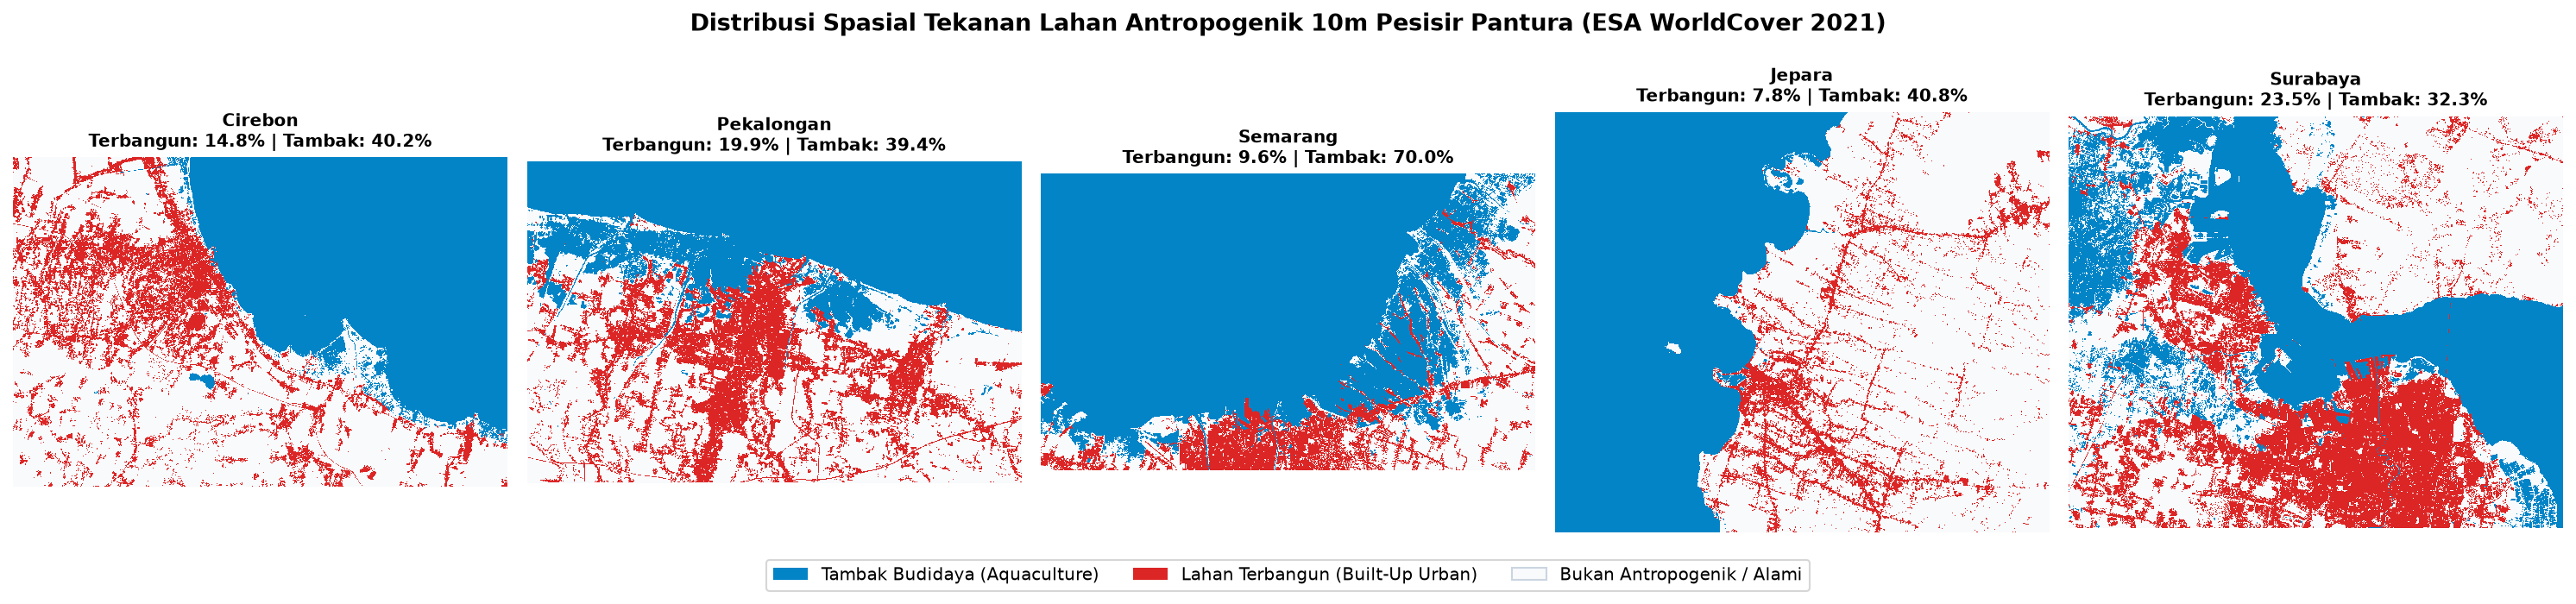

In [4]:
raster_files = {
    'Cirebon (Jabar)': 'CSPI_Full_2021_2024_Cirebon_Jabar.tif',
    'Pekalongan (Jateng)': 'CSPI_Full_2021_2024_Pekalongan_Jateng.tif',
    'Semarang - Demak (Jateng)': 'CSPI_Full_2021_2024_Semarang_Demak.tif',
    'Jepara Kontrol (Jateng)': 'CSPI_Full_2021_2024_Jepara_Kontrol.tif',
    'Surabaya (Jatim)': 'CSPI_Full_2021_2024_Surabaya_Jatim.tif'
}

anthropogenic = []
fig_land, axes_land = plt.subplots(1, 5, figsize=(20, 4.2), dpi=150)

for idx, (site, fn) in enumerate(raster_files.items()):
    fp = os.path.join(DIR_RASTER, fn)
    with tifffile.TiffFile(fp) as tif:
        arr = tif.asarray()
        total_px = arr.shape[0] * arr.shape[1]
        total_ha = total_px * 0.01
        
        tambak_mask = (arr[:, :, 3] == 1)
        tambak_ha = tambak_mask.sum() * 0.01
        
        built_mask = (arr[:, :, 4] == 1)
        built_ha = built_mask.sum() * 0.01
        
        pct_tambak = (tambak_ha / total_ha) * 100
        pct_built = (built_ha / total_ha) * 100
        total_anthro_pct = pct_built + pct_tambak
        
        pop_24 = df_pop.loc[site, 'Penduduk_2024']
        growth = df_pop.loc[site, 'Pertumbuhan_2021_2024 (%)']
        
        anthropogenic.append({
            'Wilayah': site,
            'Luas ROI (Ha)': round(total_ha, 1),
            'Lahan Terbangun (Ha)': round(built_ha, 1),
            'Proporsi Terbangun (%)': round(pct_built, 2),
            'Tambak Budidaya (Ha)': round(tambak_ha, 1),
            'Proporsi Tambak (%)': round(pct_tambak, 2),
            'Total Tekanan Antropogenik (%)': round(total_anthro_pct, 2),
            'Penduduk BPS 2021 (Jiwa)': df_pop.loc[site, 'Penduduk_2021'],
            'Penduduk BPS 2024 (Jiwa)': pop_24,
            'Pertumbuhan Penduduk (%)': growth
        })
        
        comp_map = np.zeros(arr.shape[:2], dtype=np.uint8)
        comp_map[tambak_mask] = 1
        comp_map[built_mask] = 2
        
        cmap_custom = plt.cm.colors.ListedColormap(['#f8fafc', '#0284c7', '#dc2626'])
        ax = axes_land[idx]
        ax.imshow(comp_map, cmap=cmap_custom, interpolation='nearest')
        ax.set_title(f"{site.split(' ')[0]}\nTerbangun: {pct_built:.1f}% | Tambak: {pct_tambak:.1f}%", fontsize=9.5, fontweight='bold', pad=6)
        ax.axis('off')

legend_elements = [
    Patch(facecolor='#0284c7', label='Tambak Budidaya (Aquaculture)'),
    Patch(facecolor='#dc2626', label='Lahan Terbangun (Built-Up Urban)'),
    Patch(facecolor='#f8fafc', edgecolor='#cbd5e1', label='Bukan Antropogenik / Alami')
]
fig_land.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9.5, frameon=True, bbox_to_anchor=(0.5, -0.05))
fig_land.suptitle('Distribusi Spasial Tekanan Lahan Antropogenik 10m Pesisir Pantura (ESA WorldCover 2021)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

path_fig_land = os.path.join(DIR_VISUALISASI, '03_peta_tutupan_lahan_antropogenik_10m.png')
fig_land.savefig(path_fig_land, dpi=300, bbox_inches='tight')
plt.show()

df_anthro = pd.DataFrame(anthropogenic)
display(df_anthro[['Wilayah', 'Lahan Terbangun (Ha)', 'Proporsi Terbangun (%)', 'Tambak Budidaya (Ha)', 'Proporsi Tambak (%)', 'Total Tekanan Antropogenik (%)']])
print(f"Peta spasial tutupan antropogenik tersimpan di: {path_fig_land}")

## 4. Visualisasi Grafik Dinamika Penduduk & Komposisi Tekanan Antropogenik
Memadukan visualisasi deret waktu demografi BPS dengan grafik batang bertingkat (*stacked bar chart*) proporsi lahan terbangun vs tambak budidaya.

Grafik profil antropogenik tersimpan di:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Visualisasi\03_tren_penduduk_bps_dan_tekanan_antropogenik.png


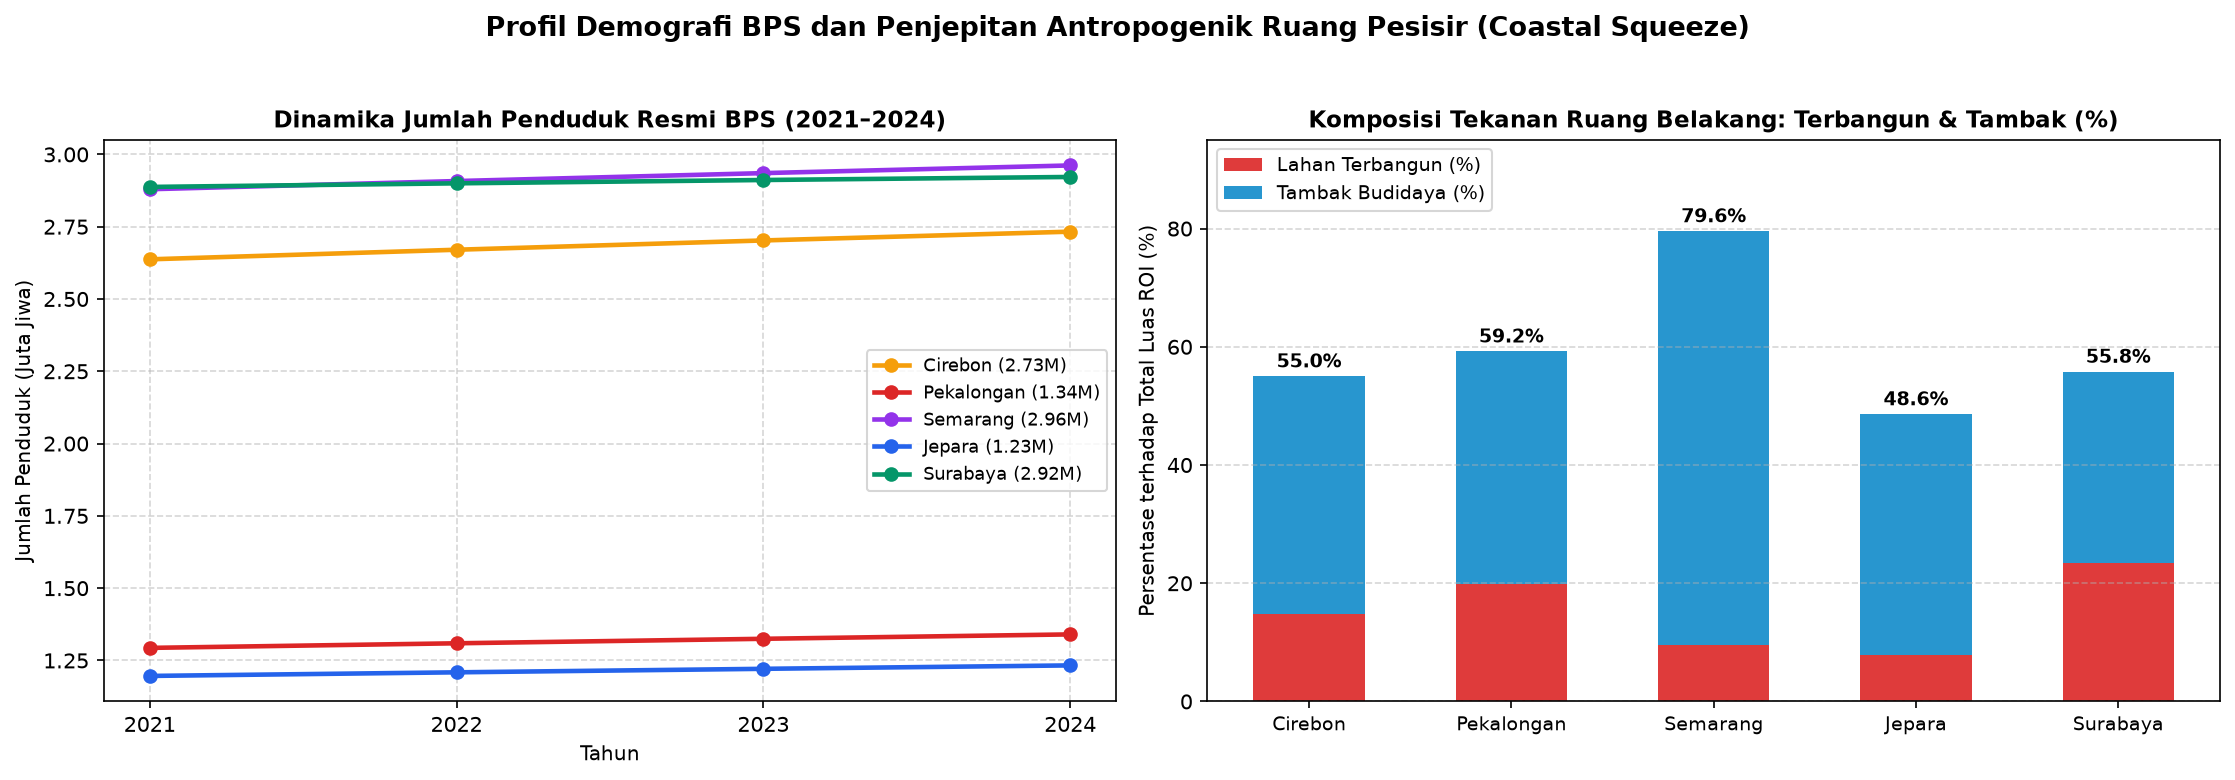

In [5]:
fig_pop, (ax_pop1, ax_pop2) = plt.subplots(1, 2, figsize=(15, 5), dpi=150)

colors_site = {'Cirebon (Jabar)': '#f59e0b', 'Pekalongan (Jateng)': '#dc2626', 
               'Semarang - Demak (Jateng)': '#9333ea', 'Jepara Kontrol (Jateng)': '#2563eb', 
               'Surabaya (Jatim)': '#059669'}

for site in regions_map:
    y_vals = [df_pop.loc[site, f'Penduduk_{y}'] / 1e6 for y in years]
    ax_pop1.plot(years, y_vals, marker='o', linewidth=2.2, color=colors_site[site], label=f"{site.split(' ')[0]} ({y_vals[-1]:.2f}M)")

ax_pop1.set_title('Dinamika Jumlah Penduduk Resmi BPS (2021–2024)', fontsize=11, fontweight='bold')
ax_pop1.set_xlabel('Tahun', fontsize=9.5)
ax_pop1.set_ylabel('Jumlah Penduduk (Juta Jiwa)', fontsize=9.5)
ax_pop1.set_xticks(years)
ax_pop1.grid(True, linestyle='--', alpha=0.5)
ax_pop1.legend(fontsize=8.5, loc='best')

x = np.arange(len(df_anthro))
labels_x = [s.split(' ')[0] for s in df_anthro['Wilayah']]
ax_pop2.bar(x, df_anthro['Proporsi Terbangun (%)'], label='Lahan Terbangun (%)', color='#dc2626', alpha=0.9, width=0.55)
ax_pop2.bar(x, df_anthro['Proporsi Tambak (%)'], bottom=df_anthro['Proporsi Terbangun (%)'], label='Tambak Budidaya (%)', color='#0284c7', alpha=0.85, width=0.55)

for i in range(len(df_anthro)):
    total_val = df_anthro.loc[i, 'Total Tekanan Antropogenik (%)']
    ax_pop2.text(i, total_val + 1.5, f"{total_val:.1f}%", ha='center', fontsize=9, fontweight='bold')

ax_pop2.set_title('Komposisi Tekanan Ruang Belakang: Terbangun & Tambak (%)', fontsize=11, fontweight='bold')
ax_pop2.set_xticks(x)
ax_pop2.set_xticklabels(labels_x, fontsize=9)
ax_pop2.set_ylabel('Persentase terhadap Total Luas ROI (%)', fontsize=9.5)
ax_pop2.set_ylim(0, 95)
ax_pop2.grid(True, axis='y', linestyle='--', alpha=0.5)
ax_pop2.legend(fontsize=9, loc='upper left')

fig_pop.suptitle('Profil Demografi BPS dan Penjepitan Antropogenik Ruang Pesisir (Coastal Squeeze)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

path_fig_pop = os.path.join(DIR_VISUALISASI, '03_tren_penduduk_bps_dan_tekanan_antropogenik.png')
fig_pop.savefig(path_fig_pop, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafik profil tersimpan di: {path_fig_pop}")

## 5. Ekspor Tabel Ekstraksi Antropogenik & Kependudukan Terstruktur
Menyimpan tabel ringkasan metrik antropogenik ke `Codes/Outputs/Statistik/` dan dataset ekstraksi pilar 3 ke `Dataset/04_Tabel_Ekstraksi_CSV_Excel/`.

In [6]:
path_stat_anthro = os.path.join(DIR_STATISTIK, '03_ringkasan_antropogenik_dan_demografi_2021_2024.csv')
df_anthro.to_csv(path_stat_anthro, index=False)

path_dataset_anthro = os.path.join(DIR_OUT_TABLES, '03_antropogenik_dan_demografi_2021_2024.csv')
df_anthro.to_csv(path_dataset_anthro, index=False)

print(f"Tabel statistik antropogenik disimpan ke:\n{path_stat_anthro}\n")
print(f"Tabel dataset ekstraksi disimpan ke:\n{path_dataset_anthro}")

Tabel statistik antropogenik disimpan ke:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik\03_ringkasan_antropogenik_dan_demografi_2021_2024.csv

Tabel dataset ekstraksi disimpan ke:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\04_Tabel_Ekstraksi_CSV_Excel\03_antropogenik_dan_demografi_2021_2024.csv


### Ringkasan Temuan Saintifik Pilar Antropogenik & Kependudukan (2021–2024):
1. **Semarang - Demak**: Memiliki tekanan ruang belakang paling masif di Pantura dengan proporsi tambak mencapai **70,00%** dan lahan terbangun **9,57%** (total penjepitan antropogenik = **79,57%**), ditambah populasi padat sebesar **2,96 juta jiwa** (2024).
2. **Surabaya**: Menjadi episentrum konsentrasi lahan terbangun tertinggi (**23,50%** atau 21.861 Ha) dengan populasi sebesar **2,92 juta jiwa**, menandakan hambatan keras mutlak berupa tanggul beton dan fasilitas pelabuhan.
3. **Pekalongan**: Memiliki kombinasi mematikan antara lahan terbangun (**19,87%**) dan tambak budidaya (**39,35%**) (total = **59,23%**), di mana pertumbuhan penduduk **3,60%** terus mendesak mangrove yang sudah mengalami penurunan tanah ekstrem (-9,78 cm/tahun).
4. **Cirebon**: Menunjukkan dominasi tambak budidaya yang luas (**40,19%**), menciptakan benteng buatan yang mengisolasi mangrove dari jalur akresi alami.
5. Seluruh indikator dari Pilar 1 (Fisik), Pilar 2 (Ekologis), dan Pilar 3 (Antropogenik) kini telah lengkap dan siap disintesis menggunakan matriks AHP & statistik spasial pada **Notebook 04**.